In [1]:
import os
os.chdir(r'C:\Users\bamla\OneDrive\Desktop\fintech-review-analytics')
print("Working from:", os.getcwd())


Working from: C:\Users\bamla\OneDrive\Desktop\fintech-review-analytics


In [2]:
import pandas as pd
import numpy as np
from google_play_scraper import reviews, Sort
from datetime import datetime
import time
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded!")

All libraries loaded!


## Task 1: Data Collection & Preprocessing
### Scraping Google Play Store Reviews for 3 Ethiopian Banks
- Commercial Bank of Ethiopia (CBE)
- Bank of Abyssinia (BOA)  
- Dashen Bank

In [3]:
# Google Play Store App IDs for each bank
APPS = {
    'CBE': 'com.combanketh.mobilebanking',
    'BOA': 'com.boa.boaMobileBanking',
    'Dashen': 'com.dashen.dashensmart'
}

def scrape_reviews(app_id, bank_name, count=600):
    """
    Scrape reviews from Google Play Store.
    Target 600 per bank to ensure 400+ after cleaning.
    """
    print(f"\nScraping {bank_name} ({app_id})...")
    all_reviews = []
    
    try:
        result, _ = reviews(
            app_id,
            lang='en',
            country='us',
            sort=Sort.NEWEST,
            count=count,
            filter_score_with=None
        )
        
        for r in result:
            all_reviews.append({
                'review':  r.get('content', ''),
                'rating':  r.get('score', None),
                'date':    r.get('at', None),
                'bank':    bank_name,
                'source':  'Google Play'
            })
        
        print(f"  Collected: {len(all_reviews)} reviews")
        time.sleep(2)  # Be polite to the server
        
    except Exception as e:
        print(f"  Error scraping {bank_name}: {e}")
    
    return all_reviews

print("Scraping function defined!")

Scraping function defined!


In [4]:
all_data = []

for bank_name, app_id in APPS.items():
    bank_reviews = scrape_reviews(app_id, bank_name, count=600)
    all_data.extend(bank_reviews)
    print(f"  Total so far: {len(all_data)}")

# Convert to DataFrame
df_raw = pd.DataFrame(all_data)
print(f"\nTotal reviews scraped: {len(df_raw)}")
print(f"Reviews per bank:\n{df_raw['bank'].value_counts()}")
df_raw.head()


Scraping CBE (com.combanketh.mobilebanking)...
  Collected: 600 reviews
  Total so far: 600

Scraping BOA (com.boa.boaMobileBanking)...
  Collected: 600 reviews
  Total so far: 1200

Scraping Dashen (com.dashen.dashensmart)...
  Collected: 0 reviews
  Total so far: 1200

Total reviews scraped: 1200
Reviews per bank:
bank
CBE    600
BOA    600
Name: count, dtype: int64


,review,rating,date,bank,source
0,pels,5,2026-05-18 08:15:35,CBE,Google Play
1,What an excellent app with smooth performance !!,5,2026-05-18 07:36:31,CBE,Google Play
2,በጣም ጥሩ ነው እነማሰግነለን,5,2026-05-18 05:55:46,CBE,Google Play
3,svabst keessatti argamu yoo ta'u yeroo ammaa k...,5,2026-05-18 01:12:03,CBE,Google Play
4,nays,5,2026-05-17 18:46:14,CBE,Google Play


## 2. Data Preprocessing

In [5]:
print("=== Raw Data Shape ===")
print(f"Rows: {len(df_raw)}, Columns: {df_raw.columns.tolist()}")

# Step 1: Check for missing values BEFORE cleaning
print("\n=== Missing Values (Before Cleaning) ===")
print(df_raw.isnull().sum())

# Step 2: Remove duplicates
dupes_before = df_raw.duplicated().sum()
df_clean = df_raw.drop_duplicates()
print(f"\nDuplicates removed: {dupes_before}")

# Step 3: Drop rows missing review text or rating
missing_review = df_clean['review'].isnull().sum()
missing_rating = df_clean['rating'].isnull().sum()
df_clean = df_clean.dropna(subset=['review', 'rating'])
print(f"Rows dropped (missing review): {missing_review}")
print(f"Rows dropped (missing rating): {missing_rating}")

# Step 4: Remove empty string reviews
empty_reviews = (df_clean['review'].str.strip() == '').sum()
df_clean = df_clean[df_clean['review'].str.strip() != '']
print(f"Empty reviews removed: {empty_reviews}")

# Step 5: Normalize dates to YYYY-MM-DD
df_clean['date'] = pd.to_datetime(df_clean['date']).dt.strftime('%Y-%m-%d')

# Step 6: Ensure rating is integer
df_clean['rating'] = df_clean['rating'].astype(int)

# Step 7: Reset index
df_clean = df_clean.reset_index(drop=True)

print(f"\n=== Clean Data Shape ===")
print(f"Rows: {len(df_clean)}, Columns: {df_clean.columns.tolist()}")
print(f"\nReviews per bank after cleaning:")
print(df_clean['bank'].value_counts())
print(f"\nRating distribution:")
print(df_clean['rating'].value_counts().sort_index())

=== Raw Data Shape ===
Rows: 1200, Columns: ['review', 'rating', 'date', 'bank', 'source']

=== Missing Values (Before Cleaning) ===
review    0
rating    0
date      0
bank      0
source    0
dtype: int64

Duplicates removed: 0
Rows dropped (missing review): 0
Rows dropped (missing rating): 0
Empty reviews removed: 0

=== Clean Data Shape ===
Rows: 1200, Columns: ['review', 'rating', 'date', 'bank', 'source']

Reviews per bank after cleaning:
bank
CBE    600
BOA    600
Name: count, dtype: int64

Rating distribution:
rating
1    274
2     38
3     65
4     92
5    731
Name: count, dtype: int64


In [6]:
print("=== Data Quality Report ===")
print(f"\nTotal reviews collected:     {len(df_raw):,}")
print(f"Total reviews after cleaning: {len(df_clean):,}")
print(f"Data retention rate:          {len(df_clean)/len(df_raw)*100:.1f}%")
print(f"Missing data rate:            {(1 - len(df_clean)/len(df_raw))*100:.1f}%")

print(f"\nDate range: {df_clean['date'].min()} to {df_clean['date'].max()}")

print(f"\nPer bank summary:")
summary = df_clean.groupby('bank').agg(
    Count=('review','count'),
    Avg_Rating=('rating','mean'),
    Min_Date=('date','min'),
    Max_Date=('date','max')
).round(2)
print(summary)

=== Data Quality Report ===

Total reviews collected:     1,200
Total reviews after cleaning: 1,200
Data retention rate:          100.0%
Missing data rate:            0.0%

Date range: 2024-11-12 to 2026-05-18

Per bank summary:
      Count  Avg_Rating    Min_Date    Max_Date
bank                                           
BOA     600        3.52  2024-11-12  2026-05-18
CBE     600        4.10  2026-02-18  2026-05-18


In [7]:
# Save cleaned data
output_path = 'data/raw/reviews_clean.csv'
os.makedirs('data/raw', exist_ok=True)
df_clean.to_csv(output_path, index=False)
print(f"Saved cleaned data to: {output_path}")
print(f"File has {len(df_clean)} rows and columns: {df_clean.columns.tolist()}")

# Preview
df_clean.head(10)

Saved cleaned data to: data/raw/reviews_clean.csv
File has 1200 rows and columns: ['review', 'rating', 'date', 'bank', 'source']


,review,rating,date,bank,source
0,pels,5,2026-05-18,CBE,Google Play
1,What an excellent app with smooth performance !!,5,2026-05-18,CBE,Google Play
2,በጣም ጥሩ ነው እነማሰግነለን,5,2026-05-18,CBE,Google Play
3,svabst keessatti argamu yoo ta'u yeroo ammaa k...,5,2026-05-18,CBE,Google Play
4,nays,5,2026-05-17,CBE,Google Play
5,very very good 👍 thanks commercial bank of eth...,5,2026-05-17,CBE,Google Play
6,so nice,5,2026-05-17,CBE,Google Play
7,fantastic,5,2026-05-17,CBE,Google Play
8,very nice,5,2026-05-17,CBE,Google Play
9,f*k,1,2026-05-17,CBE,Google Play


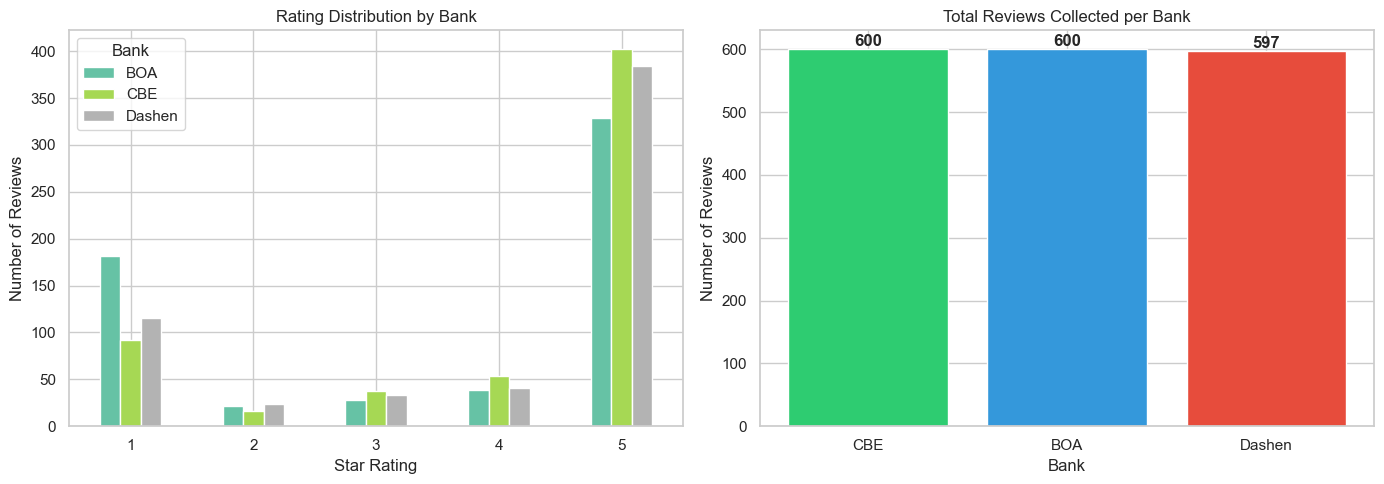

Plot saved!


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rating distribution per bank
rating_counts = df_clean.groupby(['bank','rating']).size().unstack(fill_value=0)
rating_counts.T.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='white')
axes[0].set_title('Rating Distribution by Bank')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Number of Reviews')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Bank')

# Reviews per bank
bank_counts = df_clean['bank'].value_counts()
colors = ['#2ecc71','#3498db','#e74c3c']
axes[1].bar(bank_counts.index, bank_counts.values, color=colors, edgecolor='white')
axes[1].set_title('Total Reviews Collected per Bank')
axes[1].set_xlabel('Bank')
axes[1].set_ylabel('Number of Reviews')
for i, (bank, count) in enumerate(bank_counts.items()):
    axes[1].text(i, count+5, str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('notebooks/review_distribution.png', dpi=150)
plt.show()
print("Plot saved!")

In [9]:
from google_play_scraper import search

# Search for Dashen Bank app
results = search(
    'Dashen Bank Ethiopia',
    lang='en',
    country='us',
    n_hits=5
)

for r in results:
    print(f"App ID: {r['appId']}")
    print(f"Title:  {r['title']}")
    print(f"Score:  {r.get('score', 'N/A')}")
    print("---")

App ID: com.dashen.dashensuperapp
Title:  Dashen Bank
Score:  4.13
---
App ID: com.cr2.amolelight
Title:  Dashen Mobile
Score:  4.1267605
---
App ID: com.dashen.dashenmerchant
Title:  Dashen Bank Merchant
Score:  None
---
App ID: com.combanketh.mobilebanking
Title:  Commercial Bank of Ethiopia
Score:  4.1311474
---
App ID: com.amole.agent
Title:  MobilePlus Biz
Score:  None
---


In [10]:
# Scrape Dashen with correct app ID
dashen_reviews = scrape_reviews('com.dashen.dashensuperapp', 'Dashen', count=600)
df_dashen = pd.DataFrame(dashen_reviews)
print(f"Dashen reviews collected: {len(df_dashen)}")
df_dashen.head()


Scraping Dashen (com.dashen.dashensuperapp)...
  Collected: 600 reviews
Dashen reviews collected: 600


,review,rating,date,bank,source
0,"It is a very cool application, but it requires...",4,2026-05-17 18:12:31,Dashen,Google Play
1,excellent,5,2026-05-17 16:55:52,Dashen,Google Play
2,Misguiding - Claimed anyone can convert ETB to...,1,2026-05-16 20:55:36,Dashen,Google Play
3,good,5,2026-05-16 17:57:10,Dashen,Google Play
4,ok,5,2026-05-15 20:41:19,Dashen,Google Play


In [11]:
# Preprocess Dashen reviews
df_dashen['date'] = pd.to_datetime(df_dashen['date']).dt.strftime('%Y-%m-%d')
df_dashen['rating'] = df_dashen['rating'].astype(int)
df_dashen = df_dashen[df_dashen['review'].str.strip() != '']
df_dashen = df_dashen.drop_duplicates()
df_dashen = df_dashen.reset_index(drop=True)

# Combine with existing clean data
df_clean = pd.concat([df_clean, df_dashen], ignore_index=True)

print(f"Total reviews now: {len(df_clean)}")
print(f"\nReviews per bank:")
print(df_clean['bank'].value_counts())

Total reviews now: 1797

Reviews per bank:
bank
CBE       600
BOA       600
Dashen    597
Name: count, dtype: int64


In [12]:
df_clean.to_csv('data/raw/reviews_clean.csv', index=False)
print(f"Updated CSV saved with {len(df_clean)} reviews!")
print(f"\nFinal summary:")
summary = df_clean.groupby('bank').agg(
    Count=('review','count'),
    Avg_Rating=('rating','mean'),
).round(2)
print(summary)

Updated CSV saved with 1797 reviews!

Final summary:
        Count  Avg_Rating
bank                     
BOA       600        3.52
CBE       600        4.10
Dashen    597        3.93
